# Data Analysis & Visualization

### Data Loading and Inspection

#### The following files are being read:

###### train_sequences.fasta
######  train_terms.tsv
###### train_taxonomy.tsv

In [40]:
import zipfile
import pandas as pd
from io import TextIOWrapper
from Bio import SeqIO  

zip_path = "archive (23).zip"

with zipfile.ZipFile(zip_path, 'r') as z:

   
    print("Files inside ZIP:")
    for file in z.namelist():
        print(file)

    print("\n--- Reading TSV files ---\n")
    
    with z.open('cafa-6-protein-function-prediction - Copy/Train/train_terms.tsv') as f:
        train_terms = pd.read_csv(f, sep='\t')
        print("train_terms:")
        print(train_terms.head())
 
    with z.open('cafa-6-protein-function-prediction - Copy/Train/train_taxonomy.tsv') as f:
        train_taxonomy = pd.read_csv(f, sep='\t')
        print("\ntrain_taxonomy:")
        print(train_taxonomy.head())
 
    with z.open('cafa-6-protein-function-prediction - Copy/sample_submission.tsv') as f:
        sample_submission = pd.read_csv(f, sep='\t', on_bad_lines='skip')

    with z.open('cafa-6-protein-function-prediction - Copy/Train/train_sequences.fasta') as f:
        fasta_file = TextIOWrapper(f)
        sequences = list(SeqIO.parse(fasta_file, "fasta"))

        print("First 3 sequences:")
        for seq in sequences[:3]:
            print("ID:", seq.id)
            print("Sequence:", str(seq.seq)[:50], "...\n")

    with z.open('cafa-6-protein-function-prediction - Copy/Test/testsuperset.fasta') as f:
        fasta_file = TextIOWrapper(f)
        test_sequences = list(SeqIO.parse(fasta_file, "fasta"))

        print("First 3 test sequences:")
        for seq in test_sequences[:3]:
            print("ID:", seq.id)
            print("Sequence:", str(seq.seq)[:50], "...\n")

Files inside ZIP:
cafa-6-protein-function-prediction - Copy/IA.tsv
cafa-6-protein-function-prediction - Copy/Test/testsuperset-taxon-list.tsv
cafa-6-protein-function-prediction - Copy/Test/testsuperset.fasta
cafa-6-protein-function-prediction - Copy/Train/.ipynb_checkpoints/train_sequences-checkpoint.fasta
cafa-6-protein-function-prediction - Copy/Train/go-basic.obo
cafa-6-protein-function-prediction - Copy/Train/train_sequences.fasta
cafa-6-protein-function-prediction - Copy/Train/train_taxonomy.tsv
cafa-6-protein-function-prediction - Copy/Train/train_terms.tsv
cafa-6-protein-function-prediction - Copy/sample_submission.tsv

--- Reading TSV files ---

train_terms:
  EntryID        term aspect
0  Q5W0B1  GO:0000785      C
1  Q5W0B1  GO:0004842      F
2  Q5W0B1  GO:0051865      P
3  Q5W0B1  GO:0006275      P
4  Q5W0B1  GO:0006513      P

train_taxonomy:
  A0A0C5B5G6  9606
0     A0JNW5  9606
1     A0JP26  9606
2     A0PK11  9606
3     A1A4S6  9606
4     A1A519  9606
First 3 sequences:
I

### We convert the data into a DataFrame

###### The data is converted to Pandas DataFrame
###### Data integration
###### The following are linked:
##### Protein
##### Functions (GO terms)

In [41]:
seq_df = pd.DataFrame({
    "EntryID": [seq.id for seq in sequences],
    "sequence": [str(seq.seq) for seq in sequences],
    "seq_length": [len(seq.seq) for seq in sequences]
})

print("Sequences DataFrame:")
print(seq_df.head())

labels_df = train_terms.groupby('EntryID')['term'].apply(list).reset_index()

print("\nLabels DataFrame:")
print(labels_df.head())

final_df = pd.merge(seq_df, labels_df, on='EntryID', how='inner')

print("\nFinal DataFrame:")
print(final_df.head())

Sequences DataFrame:
                     EntryID  \
0  sp|A0A0C5B5G6|MOTSC_HUMAN   
1      sp|A0JNW5|BLT3B_HUMAN   
2      sp|A0JP26|POTB3_HUMAN   
3      sp|A0PK11|CLRN2_HUMAN   
4      sp|A1A4S6|RHG10_HUMAN   

                                            sequence  seq_length  
0                                   MRWQEMGYIFYPRKLR          16  
1  MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...        1464  
2  MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...         581  
3  MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...         232  
4  MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...         786  

Labels DataFrame:
      EntryID          term
0  A0A023FBW4  [GO:0019958]
1  A0A023FBW7  [GO:0019957]
2  A0A023FDY8  [GO:0019957]
3  A0A023FF81  [GO:0019958]
4  A0A023FFB5  [GO:0019957]

Final DataFrame:
Empty DataFrame
Columns: [EntryID, sequence, seq_length, term]
Index: []


### Protein length distribution

###### EDA - Exploratory Data Analysis
###### The following are plotted:
###### Protein length distribution
###### Number of functions per protein
###### GO term frequency

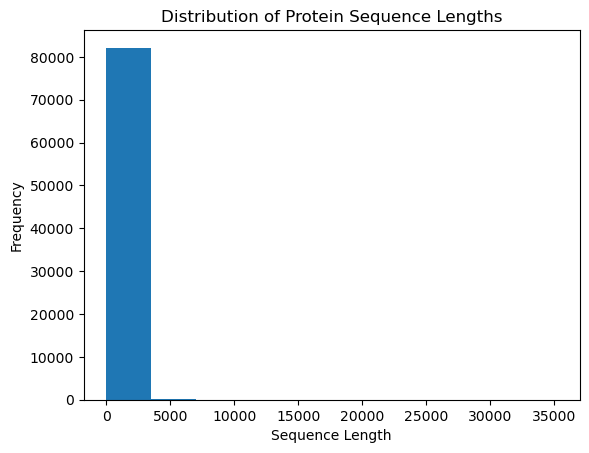

In [42]:
import pandas as pd
import matplotlib.pyplot as plt


seq_lengths = [len(seq.seq) for seq in sequences]
plt.figure()
plt.hist(seq_lengths)
plt.title("Distribution of Protein Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

### Number of functions per protein

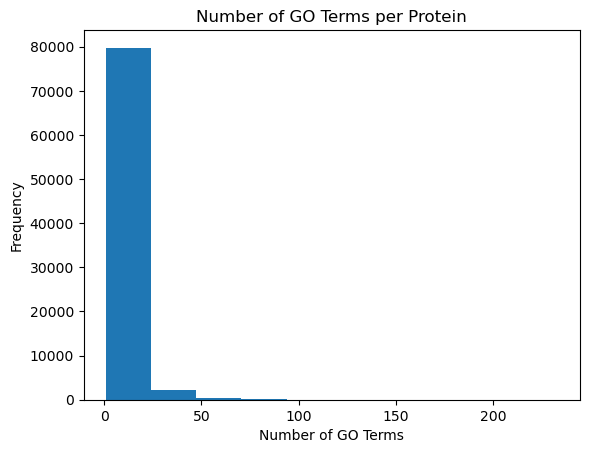

In [43]:
terms_per_protein = train_terms.groupby('EntryID').size()

plt.figure()
plt.hist(terms_per_protein)
plt.title("Number of GO Terms per Protein")
plt.xlabel("Number of GO Terms")
plt.ylabel("Frequency")
plt.show()

### Most Frequently Used GO Terms

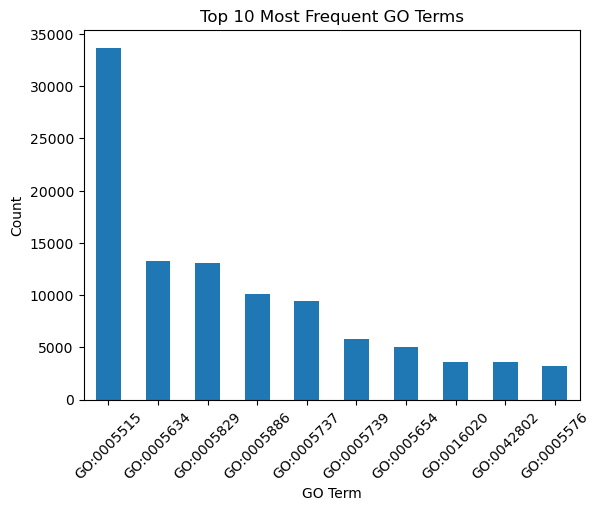

In [44]:
top_terms = train_terms['term'].value_counts().head(10)

plt.figure()
top_terms.plot(kind='bar')
plt.title("Top 10 Most Frequent GO Terms")
plt.xlabel("GO Term")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Basic data statistics

In [45]:


# 1. Number of training and test proteins
num_train_proteins = len(sequences)
num_test_proteins = len(test_sequences)
print(f" Number of training proteins: {num_train_proteins:,}")
print(f" Number of test proteins: {num_test_proteins:,}")
print('=====================================================')
# 2. Sequence length statistics (training set)
seq_lengths = [len(seq.seq) for seq in sequences]
min_len = min(seq_lengths)
max_len = max(seq_lengths)
mean_len = sum(seq_lengths) / len(seq_lengths)
median_len = sorted(seq_lengths)[len(seq_lengths)//2]
print('=====================================================')
print(f"\n Sequence length statistics:")
print(f"   Shortest sequence: {min_len} amino acids")
print(f"   Longest sequence: {max_len} amino acids")
print(f"   Mean length: {mean_len:.1f} amino acids")
print(f"   Approximate mean: ≈ {int(mean_len)} amino acids")
print(f"   Median length: {median_len} amino acids")
print('=====================================================')
# 3. GO terms statistics
distinct_go_terms = train_terms['term'].nunique()
print(f"\n Total distinct GO terms: {distinct_go_terms:,}")
print('=====================================================')
# 4. Distribution of GO terms per protein
terms_per_protein = train_terms.groupby('EntryID').size()
print(f"\n GO terms per protein distribution:")
print(f"   Minimum: {terms_per_protein.min()}")
print(f"   Maximum: {terms_per_protein.max()}")
print(f"   Mean: {terms_per_protein.mean():.2f}")
print(f"   Median: {terms_per_protein.median():.0f}")
print('=====================================================')
# 5. Imbalance: most frequent GO terms
top_go_terms = train_terms['term'].value_counts().head(10)
print(f"\n Top 10 most frequent GO terms (showing imbalance):")
for term, count in top_go_terms.items():
    print(f"   {term}: {count} times")

 Number of training proteins: 82,404
 Number of test proteins: 224,309

 Sequence length statistics:
   Shortest sequence: 3 amino acids
   Longest sequence: 35213 amino acids
   Mean length: 525.8 amino acids
   Approximate mean: ≈ 525 amino acids
   Median length: 409 amino acids

 Total distinct GO terms: 26,125

 GO terms per protein distribution:
   Minimum: 1
   Maximum: 233
   Mean: 6.52
   Median: 4

 Top 10 most frequent GO terms (showing imbalance):
   GO:0005515: 33713 times
   GO:0005634: 13283 times
   GO:0005829: 13040 times
   GO:0005886: 10150 times
   GO:0005737: 9442 times
   GO:0005739: 5807 times
   GO:0005654: 5065 times
   GO:0016020: 3563 times
   GO:0042802: 3547 times
   GO:0005576: 3241 times


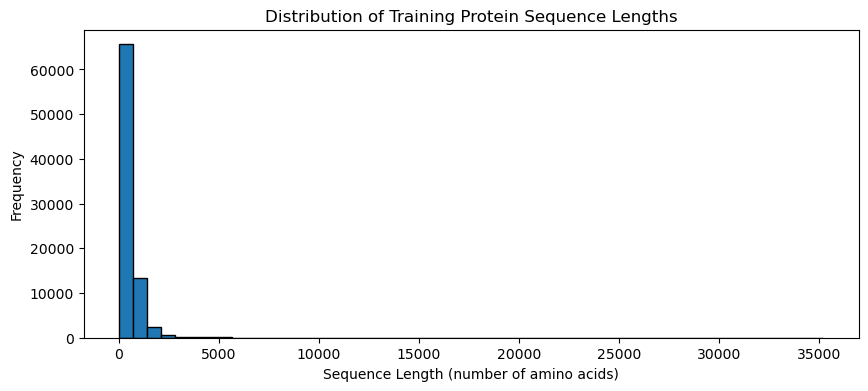

In [46]:
# Distribution of training protein sequence lengths
plt.figure(figsize=(10,4))
plt.hist(seq_lengths, bins=50, edgecolor='black')
plt.title('Distribution of Training Protein Sequence Lengths')
plt.xlabel('Sequence Length (number of amino acids)')
plt.ylabel('Frequency')
plt.show()

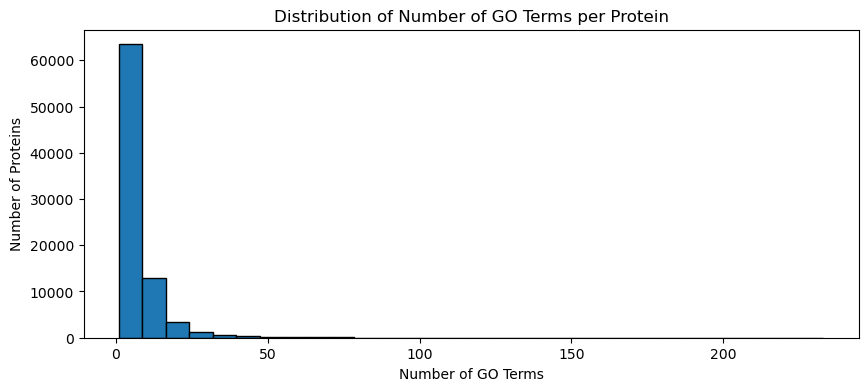

In [47]:
# Distribution of number of GO terms per protein
plt.figure(figsize=(10,4))
plt.hist(terms_per_protein, bins=30, edgecolor='black')
plt.title('Distribution of Number of GO Terms per Protein')
plt.xlabel('Number of GO Terms')
plt.ylabel('Number of Proteins')
plt.show()

# Preprocessing

### Data Augmentation

In [48]:
def random_substitution(seq):
    if len(seq) == 0:
        return seq
    pos = random.randint(0, len(seq)-1)
    new_aa = random.choice(amino_acids)
    seq = list(seq)
    seq[pos] = new_aa
    return "".join(seq)

def random_deletion(seq):
    if len(seq) <= 1:
        return seq
    pos = random.randint(0, len(seq)-1)
    return seq[:pos] + seq[pos+1:]

def random_insertion(seq):
    pos = random.randint(0, len(seq))
    aa = random.choice(amino_acids)
    return seq[:pos] + aa + seq[pos:]


def augment_sequence(seq):
    operations = [random_substitution, random_deletion, random_insertion]
    op = random.choice(operations)
    return op(seq)

### Generate an augmented version for each sequence

In [49]:
augmented_rows = []

for _, row in seq_df.iterrows():
    new_seq = augment_sequence(row["sequence"])
    augmented_rows.append({
        "EntryID": row["EntryID"] + "_aug",
        "sequence": new_seq
    })

aug_df = pd.DataFrame(augmented_rows)

###  Merge original data with augmented

In [50]:
seq_df = pd.concat([seq_df, aug_df], ignore_index=True)

### Feature Engineering

In [51]:
def sequence_features(seq):
    length = len(seq)
    features = {"seq_length": length}

    for aa in amino_acids:
        features[f"freq_{aa}"] = seq.count(aa) / length if length > 0 else 0

    return features


features = seq_df["sequence"].apply(sequence_features)
features_df = pd.DataFrame(features.tolist())

features_df["EntryID"] = seq_df["EntryID"]


### Labels processing

In [52]:
labels_df = train_terms.groupby("EntryID")["term"].apply(list).reset_index()

### Repeated labels for augmented data

In [53]:
aug_labels = labels_df.copy()
aug_labels["EntryID"] = aug_labels["EntryID"] + "_aug"

labels_df = pd.concat([labels_df, aug_labels])
mlb = MultiLabelBinarizer()

### Multi-label encoding

In [54]:
# حساب تكرار كل label
label_counts = labels_df["term"].explode().value_counts()

# اختيار Top 1000 فقط
top_labels = label_counts.head(1000).index

# فلترة البيانات
labels_df["term"] = labels_df["term"].apply(
    lambda terms: [t for t in terms if t in top_labels]
)

# حذف الصفوف الفارغة
labels_df = labels_df[labels_df["term"].map(len) > 0]

mlb = MultiLabelBinarizer(sparse_output=True)
Y_sparse = mlb.fit_transform(labels_df["term"])

Y = Y_sparse